# Toy Model: Analysis

In [27]:
sup_method='moekratter' # options: 'simple', 'moekratter', '50', 'snow  '

from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
from scipy import stats
import scipy


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_hist_confidence, plot_ecdf_confidence, ecdf_grid
from sbin.complexity import create_complexity_df
from sbin.statistics_utilities import *


if sup_method=='simple':
    from sbin.suppression_utilities import suppression_factor_simple as my_suppression_factor
elif sup_method=='moekratter':
    from sbin.suppression_utilities import suppression_factor_mk21 as my_suppression_factor
elif sup_method=='50':
    from sbin.suppression_utilities import suppression_factor_50 as my_suppression_factor  
elif sup_method=='snow':
    from sbin.suppression_utilities import suppression_factor_snow as my_suppression_factor
else:
    raise



### Read in data saved from Filtering

In [43]:
with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
          
# conjoined list of binaries
binaries = data["binaries_filtered"]

allbinaries = data["binaries_unfiltered"]

# separation values (one per KOI) for each binary
binary_separations = binaries.groupby('KOI')['SepAU'].first().values
allbinaries_separations = allbinaries.groupby('KOI')['SepAU'].first().values

# all KOIs that are presumed single
singles = data["kois_filtered_cc"]
#singles = singles[ (singles['teff']<4000) & (singles['teff']<7000)]


# Toy Model

### Suppress the KOIs

In [51]:

# ------------------------------------------------------------------
#  Initialise the simulator
# ------------------------------------------------------------------
KeplerSimulator = SuppressionSimulator(
    planets_cat=singles,
    sup_function=my_suppression_factor,
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

# ------------------------------------------------------------------
#  Run it
# ------------------------------------------------------------------
max_a_draw = 100.
res_systems, res_planets  = run_trials(
    simulator=KeplerSimulator,
    n_trials=1000,
    max_a_draw=max_a_draw)

## Semi-major axis plots

P-value (planets suppress?ed, N=37):
 KstestResult(statistic=0.11121270631797892, pvalue=0.7084372200499676, statistic_location=23.709799607888527, statistic_sign=-1)
133368
P-value (planets suppress?ed, N=84):
 KstestResult(statistic=0.14254865163628883, pvalue=0.059450358113453894, statistic_location=35.705533873003645, statistic_sign=-1)


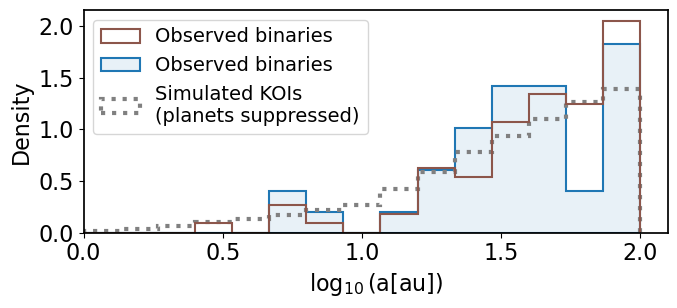

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
log_min, log_max = 0., np.log10(max_a_draw)              
n_bins = 15                             
bins   = np.linspace(log_min, log_max, n_bins + 1)   # bin edges

ax.set_xlabel(r'$\log_{10}(a [au])$')
ax.set_ylabel('Density')

obs = binary_separations[binary_separations<max_a_draw]
sim = res_systems.survived_systems['a_values']
plt.hist(np.log10(sim), bins=bins,
         histtype='step', density=True, ls=':',
         color='gray',  lw=3, label='Simulated KOIs\n(planets suppressed)')


plt.hist(np.log10(obs), bins=bins, 
         density=True, histtype='stepfilled', ls='-',
         edgecolor='C0', facecolor='#e8f1f7', 
         alpha=1, lw=1.5, label='Observed binaries')

obs2 = allbinaries_separations[allbinaries_separations<max_a_draw]
plt.hist(np.log10(obs2), bins=bins, 
         density=True, histtype='step', ls='-:',
         edgecolor='C5', 
         alpha=1, lw=1.5, label='Observed binaries')


handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(handles[::-1], labels[::-1], loc='upper left')
plt.xlim(log_min, log_max+0.1)
plt.tight_layout()

print("P-value (planets suppress?ed, N=" + str(len(obs)) + "):\n", stats.ks_2samp(obs, sim))
print(len(sim))

print("P-value (planets suppress?ed, N=" + str(len(obs2)) + "):\n", stats.ks_2samp(obs2, sim))

#plt.savefig("separation_test.png")

## Multiplicity plots

Observed p value: 0.5552459749937236 0.00029576181737966446


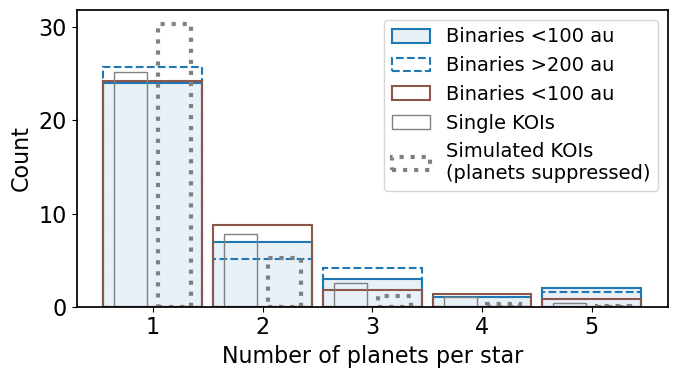

In [ ]:

bin_label = 'Binaries <100 au'
bin_col = 'C0'
koi_label = 'Single KOIs'
close = binaries['SepAU']<100.
    
def plot_multiplicity_hist(planet_counts, norm_to=True, offset=0, plot_error=False, **kwargs):
    nstars = len(planet_counts)
    if norm_to:
        ww = norm_to/np.full(nstars, nstars, dtype=float)
    else:
        ww = np.ones(nstars)

    y, _ = np.histogram(planet_counts['n_planets'], 
                        weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
    ax.bar(x + offset, y, **kwargs)

    if plot_error:
        ax.errorbar(x + offset, y, yerr=np.sqrt(y), 
                    fmt='none', 
                    ecolor=kwargs.get('edgecolor','C0'), 
                    capsize=5, elinewidth=1.5,
                    zorder=1)



fig, ax = plt.subplots(1, 1, figsize=(7,4), sharex=True, sharey=True)
x = np.array([1,2,3,4,5])

## the binaries

bin_planet_counts = binaries[close].groupby('KOI').size().reset_index(name='n_planets')
plot_multiplicity_hist(bin_planet_counts, 
                        norm_to=False, plot_error=False,
                        edgecolor=bin_col, facecolor='#e8f1f7', alpha=1, 
                        width=0.9, linewidth=1.5,
                        label=bin_label)

wide = binaries['SepAU']>200.
wide_planet_counts = binaries[wide].groupby('KOI').size().reset_index(name='n_planets')
plot_multiplicity_hist(wide_planet_counts, 
                        norm_to=len(bin_planet_counts),
                        edgecolor=bin_col, facecolor='None', alpha=1, 
                        width=0.9, linewidth=1.5, ls='--',
                        label='Binaries >200 au')

#abin_planet_counts = allbinaries[allbinaries['SepAU']<100.].groupby('KOI').size().reset_index(name='n_planets')
#plot_multiplicity_hist(abin_planet_counts, 
#                        norm_to=len(bin_planet_counts),
#                        edgecolor='C5', facecolor='None', alpha=1, 
#                        width=0.9, linewidth=1.5, ls='-',
#                        label='Binaries <100 au')



plot_multiplicity_hist(res_systems.survived_systems, 
                        norm_to=len(bin_planet_counts),
                        offset=-0.2,
                        ls='-', edgecolor='gray', facecolor='None',  
                        width=0.3, lw=1, label=koi_label)

plot_multiplicity_hist(res_planets.survived_systems, 
                        norm_to=len(bin_planet_counts),
                        offset=0.2,
                        ls=':', edgecolor='gray', facecolor='none',  
                        width=0.3, lw=3,
                        label='Simulated KOIs \n(planets suppressed)')

plt.xlabel('Number of planets per star')
plt.ylabel('Count')
plt.legend()
#plt.ylim(0,0.9)
plt.tight_layout()

plt.savefig(f'plots/multiplicity_{sup_method}.png')



p_chi2_systems = chisquare_multiplicity(bin_planet_counts, res_systems.survived_systems)
p_chi2_planets = chisquare_multiplicity(bin_planet_counts, res_planets.survived_systems)
print("Observed p value:", p_chi2_systems, p_chi2_planets)



## Complexity

/Users/f003p9d/Research/importance_of_binarity/sbin/complexity.py:78: RuntimeWarning: divide by zero encountered in log
  entropy = np.sum(p_star * np.log(p_star))
/Users/f003p9d/Research/importance_of_binarity/sbin/complexity.py:78: RuntimeWarning: invalid value encountered in multiply
  entropy = np.sum(p_star * np.log(p_star))


P-value (planets suppressed, N=6264): KstestResult(statistic=0.3160919540229885, pvalue=0.4891948699747795, statistic_location=0.0762941618097414, statistic_sign=1)
P-value (systems suppressed, N=14321): KstestResult(statistic=0.4143681772688127, pvalue=0.1912003532639116, statistic_location=0.07153942672762093, statistic_sign=1)


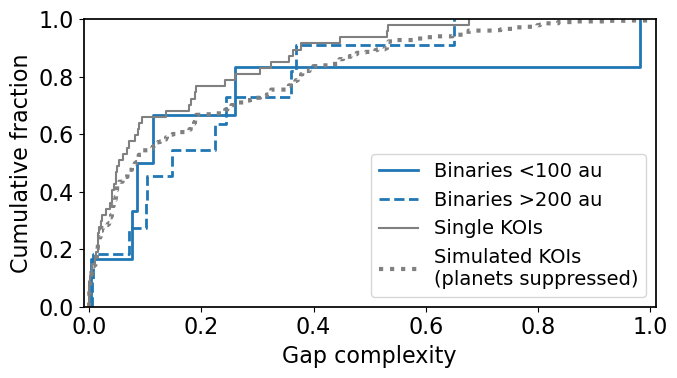

In [60]:
koi_df = create_complexity_df(singles)
koi_complexity = koi_df[koi_df['n_planets']>2]['gap_complexity'].values

def complexity_helper(sample, just_need_n=False, **kwargs):
    df = create_complexity_df(sample)
    complexity = df[np.isfinite(df['gap_complexity'])]['gap_complexity'].values
    if just_need_n:
        return len(complexity)
    
    sns.ecdfplot(complexity, **kwargs)

    return(complexity)

col = 'C0'
    
fig, ax = plt.subplots(figsize=(7, 4))

close_complexity = complexity_helper(binaries[binaries['SepAU']<100.], 
                  ax=ax, label='Binaries <100 au', linewidth=2, color=col)

wide_complexity = complexity_helper(binaries[binaries['SepAU']>=200.], 
                  ax=ax, label='Binaries >200 au', linewidth=2, ls='--',color=col)


sns.ecdfplot(koi_complexity, ax=ax,
             label='Single KOIs', color='gray')

plt.xlabel('Cumulative Fraction')
plt.ylabel('Complexity')

n_to_sample = complexity_helper(binaries[binaries['SepAU']<100.], just_need_n=True)

def complexity_sampler(res):

    samples = []
    for trial in res.survived_periods:
        df = create_complexity_df(trial)
        sample = df[np.isfinite(df['gap_complexity'])]['gap_complexity'].values

        samples =np.concatenate([samples, sample])

    return np.asarray(samples).flatten()

samples = complexity_sampler(res_planets)
print("P-value (planets suppressed, N=" + str(len(samples)) + "):", stats.ks_2samp(samples, close_complexity))
sns.ecdfplot(samples, ax=ax,
             label='Simulated KOIs \n(planets suppressed)', 
             color='gray', ls=':', lw=3)

samples = complexity_sampler(res_systems)
print("P-value (systems suppressed, N=" + str(len(samples)) + "):", stats.ks_2samp(samples, close_complexity))

plt.legend()
plt.xlim(-0.01,1.01)
plt.ylim(0,1)
plt.xlabel('Gap complexity')
plt.ylabel('Cumulative fraction')
                     
# and the appropriate stats

plt.tight_layout()
plt.savefig(f'plots/complexity_{sup_method}.png')